In [9]:
import numpy as np
import torch.optim as optim
import torch.nn as nn
import torch
import matplotlib.pyplot as plt

In [10]:
x = torch.linspace(-1,1,100).reshape(100,1)
y = (x**2)

In [11]:
model = nn.Sequential(
        (nn.Linear(1,16)),
        (nn.ReLU()),
        (nn.Linear(16,16)),
        (nn.ReLU()),
        (nn.Linear(16,1)),
)
print(model)

for param in model.parameters():
        print(param.shape, param)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable Parameters: {trainable_params}")

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)
torch.Size([16, 1]) Parameter containing:
tensor([[ 0.7288],
        [-0.0626],
        [ 0.6633],
        [-0.3404],
        [-0.2498],
        [-0.6532],
        [-0.1013],
        [-0.5509],
        [ 0.4938],
        [-0.2067],
        [ 0.3269],
        [-0.4659],
        [ 0.7185],
        [-0.6583],
        [-0.9848],
        [-0.4830]], requires_grad=True)
torch.Size([16]) Parameter containing:
tensor([ 0.4867, -0.1368,  0.4628,  0.7666,  0.3879,  0.7025, -0.4036, -0.3171,
        -0.5631, -0.5946, -0.4059,  0.8213,  0.5872, -0.7570, -0.3834,  0.3348],
       requires_grad=True)
torch.Size([16, 16]) Parameter containing:
tensor([[ 3.0291e-02,  2.1416e-01,  1.9847e-01,  8.5239e-02,  1.6682e-01,
          1.8011e-02, -1.1266e-02,  2.3884e-01,  3.7660e-02,  1.8797e-02,
 

In [12]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(params=model.parameters(),lr=0.001)

In [13]:
def train(input: torch.Tensor,
          expected: torch.Tensor,
          model: nn.Sequential,
          loss_fn: nn.MSELoss,
          optimizer: optim.Adam
        ) -> losses:

    size = len(input)
    losses = []
    for i,epoch in enumerate(range(10000)):
        model.train()

        pred = model(input)
        loss = loss_fn(pred,expected)
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    return losses

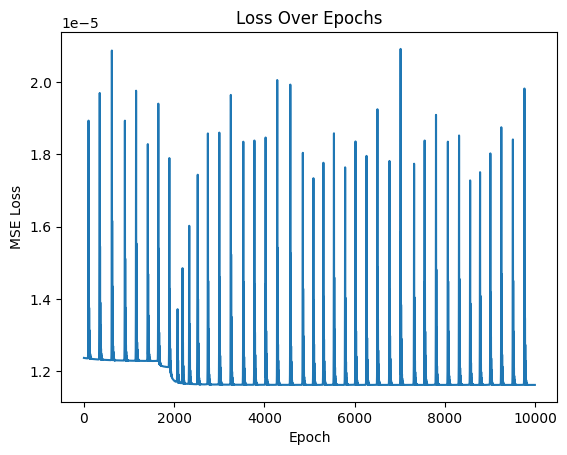

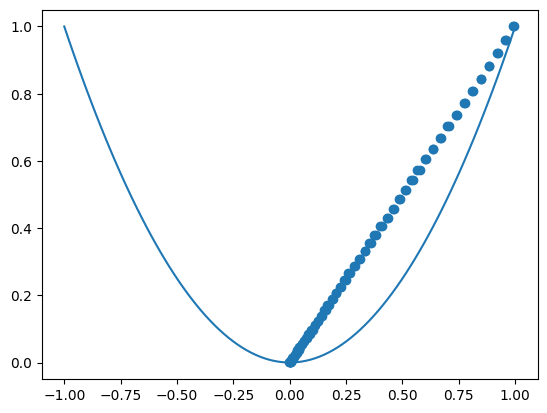

In [15]:
hist = train(x,y,model,loss_fn,optimizer)
plt.plot(hist)
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()
plt.plot(x,y)
plt.scatter(model(x).detach(),y)